In [17]:
import pandas as pd
import numpy as np

# ============================================================
# TEMPORARY: Fake data for testing code structure
# Replace with real data load when CSV is available
# Delete this cell when real data arrives
# ============================================================

np.random.seed(42)
n_stocks = 100
n_months = 80  # enough for 60 month training window + test

permnos = np.repeat(np.arange(1, n_stocks + 1), n_months)
dates = pd.date_range("2000-01-01", periods=n_months, freq="MS")
dates = np.tile(dates, n_stocks)

df = pd.DataFrame({
    "permno":   permnos,
    "date":     dates,
    "ret":      np.random.normal(0.01, 0.05, n_stocks * n_months),
    "price":    np.random.uniform(10, 200, n_stocks * n_months),
    "shrout":   np.random.uniform(1e6, 1e8, n_stocks * n_months),
    "retvol":   np.random.uniform(0.01, 0.08, n_stocks * n_months),
    "vol":      np.random.uniform(1e5, 1e7, n_stocks * n_months),
    "me":       np.random.uniform(1e8, 1e11, n_stocks * n_months),
})

# Skip the CSV load in Cell 2 — data is already in df
print("Fake data created for testing.")
print(f"Shape: {df.shape}")
print(df.columns.tolist())

Fake data created for testing.
Shape: (8000, 8)
['permno', 'date', 'ret', 'price', 'shrout', 'retvol', 'vol', 'me']


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# ASSUMPTIONS — MODEL A
# ============================================================
# 1. Target variable: log(annualized vol). Log is used because
#    volatility is right-skewed and the persistence relationship
#    is closer to linear on a log scale. Predictions are
#    exponentiated back before use in the portfolio.
#    Source: standard practice in volatility forecasting literature.
#
# 2. Annualization: retvol * sqrt(252). retvol from CRSP is the
#    standard deviation of daily returns within the month.
#
# 3. Features: individual stock history only. No market-level
#    features. This is noted for potential inclusion in Model B.
#
# 4. Lag horizons: 1, 3, 6 months. Motivated by HAR model
#    (Corsi, 2009).
#
# 5. Models: Ridge and LASSO. Both compared against naive baseline.
#
# 6. Lambda grid: np.logspace(-4, 4, 100). Standard range covering
#    very weak to very strong regularization. Easy to adjust.
#
# 7. Validation: TimeSeriesSplit with 5 folds.
#
# 8. Train/test split: expanding window with minimum 60 months
#    (5 years) initial training window.
#
# 9. Naive baseline: last month's realized vol (vol_lag1) as the
#    prediction for next month. This is a strong benchmark because
#    volatility is persistent.
#
# 10. No regime check in Model A. The capital cost rate is always
#     15%. Regime detection is noted for Model B.
#
# 11. No invest/exit rule based on market vol in Model A. Model A
#     always invests when expected net revenue per stock is positive.
# ============================================================

print("Imports and assumptions loaded.")

Imports and assumptions loaded.


In [20]:
# Load your cleaned monthly panel
df = pd.read_csv("crsp_monthly_clean.csv", parse_dates=["mthcaldt"])

# Rename CRSP v2 columns to standard names
df = df.rename(columns={
    "mthprc":   "price",
    "mthret":   "ret",
    "mthcaldt": "date",
})

df = df.sort_values(["permno", "date"]).reset_index(drop=True)

# ---- CHECK 1: Basic shape and date range ----
print("=== CHECK 1: Basic Info ===")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique stocks: {df['permno'].nunique()}")
print(f"Unique months: {df['date'].nunique()}")
print()

# ---- CHECK 2: Required columns exist ----
# Note: retvol and vol will be missing until teammate re-downloads
required_cols = ["permno", "date", "ret", "price", "shrout",
                 "retvol", "vol", "me"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f"WARNING: Missing columns (expected until new download): {missing}")
else:
    print("=== CHECK 2: All required columns present ===")
print()

# ---- CHECK 3: Stock count per month ----
stock_count = df.groupby("date")["permno"].nunique()
print("=== CHECK 3: Stock count per month ===")
print(f"Min stocks in any month: {stock_count.min()}")
print(f"Max stocks in any month: {stock_count.max()}")
print(f"Mean stocks per month: {stock_count.mean():.0f}")
stock_count.plot(figsize=(10, 4), title="Stocks per Month")
plt.ylabel("Number of Stocks")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'crsp_monthly_clean.csv'

In [21]:
# ============================================================
# FEATURE ENGINEERING
# All features are lagged to avoid data leakage.
# Target is next month's log annualized vol (shift -1).
# ============================================================

df = df.sort_values(["permno", "date"]).reset_index(drop=True)

# --- Annualized realized vol ---
df["realized_vol_ann"] = df["retvol"] * np.sqrt(252)

# --- Target: log of next month's annualized vol ---
df["log_vol"] = np.log(df["realized_vol_ann"])
df["target_log_vol"] = df.groupby("permno")["log_vol"].shift(-1)

# --- Vol lag features (HAR-motivated) ---
df["vol_lag1"] = df.groupby("permno")["realized_vol_ann"].shift(1)
df["vol_lag3"] = (df.groupby("permno")["realized_vol_ann"]
                  .shift(1)
                  .rolling(3)
                  .mean()
                  .reset_index(0, drop=True))
df["vol_lag6"] = (df.groupby("permno")["realized_vol_ann"]
                  .shift(1)
                  .rolling(6)
                  .mean()
                  .reset_index(0, drop=True))

# --- Log vol lags (on log scale, consistent with target) ---
df["log_vol_lag1"] = df.groupby("permno")["log_vol"].shift(1)
df["log_vol_lag3"] = (df.groupby("permno")["log_vol"]
                      .shift(1)
                      .rolling(3)
                      .mean()
                      .reset_index(0, drop=True))
df["log_vol_lag6"] = (df.groupby("permno")["log_vol"]
                      .shift(1)
                      .rolling(6)
                      .mean()
                      .reset_index(0, drop=True))

# --- Return-based features ---
df["abs_ret_lag1"] = df.groupby("permno")["ret"].shift(1).abs()
df["momentum_12m"] = (df.groupby("permno")["ret"]
                      .shift(1)
                      .rolling(12)
                      .sum()
                      .reset_index(0, drop=True))

# --- Size and price features ---
df["log_me_lag1"] = np.log(df.groupby("permno")["me"].shift(1))
df["log_price_lag1"] = np.log(
    df.groupby("permno")["price"].shift(1).abs()
)

# --- Turnover ---
df["turnover_lag1"] = (
    df.groupby("permno")["vol"].shift(1) /
    df.groupby("permno")["shrout"].shift(1)
)

# ---- CHECK 4: Feature distributions ----
features = ["log_vol_lag1", "log_vol_lag3", "log_vol_lag6",
            "abs_ret_lag1", "momentum_12m",
            "log_me_lag1", "log_price_lag1", "turnover_lag1"]

print("=== CHECK 4: Feature Summary Statistics ===")
print(df[features + ["target_log_vol"]].describe().round(4))

=== CHECK 4: Feature Summary Statistics ===
       log_vol_lag1  log_vol_lag3  log_vol_lag6  abs_ret_lag1  momentum_12m  \
count     7900.0000     7700.0000     7400.0000     7900.0000     6800.0000   
mean        -0.4695       -0.4689       -0.4680        0.0409        0.1176   
std          0.5405        0.3096        0.2164        0.0310        0.1682   
min         -1.8404       -1.6622       -1.4138        0.0000       -0.4253   
25%         -0.8402       -0.6724       -0.6087        0.0165        0.0008   
50%         -0.3380       -0.4507       -0.4608        0.0343        0.1196   
75%         -0.0175       -0.2393       -0.3181        0.0589        0.2279   
max          0.2388        0.2123        0.1512        0.2063        0.7251   

       log_me_lag1  log_price_lag1  turnover_lag1  target_log_vol  
count    7900.0000       7900.0000      7900.0000       7900.0000  
mean       24.3277          4.4636         0.2335         -0.4700  
std         0.9750          0.7088      

In [22]:
# ============================================================
# Drop rows with any NaN in features or target.
# NaNs arise from:
# - Rolling windows needing warmup (vol_lag6 needs 7 months)
# - momentum_12m needs 13 months
# - Last month of each stock has no target (shift -1)
# ============================================================

model_cols = features + ["target_log_vol", "permno", "date",
                         "realized_vol_ann"]

df_model = df[model_cols].dropna().copy()
df_model = df_model.sort_values(["date", "permno"]).reset_index(drop=True)

# ---- CHECK 5: Size after dropping NaNs ----
print("=== CHECK 5: Dataset After Dropping NaNs ===")
print(f"Rows before: {len(df)}")
print(f"Rows after:  {len(df_model)}")
print(f"Date range:  {df_model['date'].min()} to {df_model['date'].max()}")
print(f"Unique stocks: {df_model['permno'].nunique()}")
print()

# ---- CHECK 6: No remaining NaNs ----
nan_count = df_model[features + ["target_log_vol"]].isna().sum()
print("=== CHECK 6: NaN Count Per Column (should all be 0) ===")
print(nan_count)

=== CHECK 5: Dataset After Dropping NaNs ===
Rows before: 8000
Rows after:  6700
Date range:  2001-01-01 00:00:00 to 2006-07-01 00:00:00
Unique stocks: 100

=== CHECK 6: NaN Count Per Column (should all be 0) ===
log_vol_lag1      0
log_vol_lag3      0
log_vol_lag6      0
abs_ret_lag1      0
momentum_12m      0
log_me_lag1       0
log_price_lag1    0
turnover_lag1     0
target_log_vol    0
dtype: int64


In [24]:
# ============================================================
# EXPANDING WINDOW SETUP
# Minimum training window: 60 months (5 years)
# Each step: train on all months up to t, predict month t+1
# ============================================================

# Get sorted unique months
all_months = sorted(df_model["date"].unique())
n_months = len(all_months)
min_train_months = 60  # assumption: 5 year minimum

# All months we will make predictions for
test_months = all_months[min_train_months:]

print("=== CHECK 7: Expanding Window Setup ===")
print(f"Total months available: {n_months}")
print(f"Minimum training window: {min_train_months} months")
print(f"First prediction month: {test_months[0]}")
print(f"Last prediction month:  {test_months[-1]}")
print(f"Number of prediction months: {len(test_months)}")

=== CHECK 7: Expanding Window Setup ===
Total months available: 67
Minimum training window: 60 months
First prediction month: 2006-01-01 00:00:00
Last prediction month:  2006-07-01 00:00:00
Number of prediction months: 7


In [25]:
# ============================================================
# EXPANDING WINDOW LOOP
# For each test month:
#   1. Build train set (all months before test month)
#   2. Tune lambda via TimeSeriesSplit CV on training set
#   3. Fit Ridge and LASSO on full training set
#   4. Predict log vol for test month
#   5. Store predictions
# ============================================================

LAMBDAS = np.logspace(-4, 4, 100)  # assumption: standard lambda grid
N_CV_FOLDS = 5                      # assumption: 5 folds

results = []

for i, test_month in enumerate(test_months):

    # --- Split ---
    train_mask = df_model["date"] < test_month
    test_mask  = df_model["date"] == test_month

    df_train = df_model[train_mask].copy()
    df_test  = df_model[test_mask].copy()

    if len(df_test) == 0:
        continue

    X_train = df_train[features].values
    y_train = df_train["target_log_vol"].values
    X_test  = df_test[features].values
    y_test  = df_test["target_log_vol"].values

    # --- Scale (fit on train only) ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # --- Time series CV splitter ---
    tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)

    # --- Ridge ---
    ridge = RidgeCV(alphas=LAMBDAS, cv=tscv)
    ridge.fit(X_train_sc, y_train)
    pred_ridge = ridge.predict(X_test_sc)

    # --- LASSO ---
    lasso = LassoCV(alphas=LAMBDAS, cv=tscv, max_iter=5000)
    lasso.fit(X_train_sc, y_train)
    pred_lasso = lasso.predict(X_test_sc)

    # --- Naive baseline: log of vol_lag1 ---
    pred_naive = df_test["log_vol_lag1"].values

    # --- Store ---
    month_df = df_test[["permno", "date", "target_log_vol",
                         "realized_vol_ann"]].copy()
    month_df["pred_log_vol_ridge"] = pred_ridge
    month_df["pred_log_vol_lasso"] = pred_lasso
    month_df["pred_log_vol_naive"] = pred_naive
    month_df["ridge_best_lambda"]  = ridge.alpha_
    month_df["lasso_best_lambda"]  = lasso.alpha_

    results.append(month_df)

    # Progress print every 12 months
    if (i + 1) % 12 == 0:
        print(f"Completed {i+1}/{len(test_months)} months "
              f"— last month: {test_month.date()}")

df_results = pd.concat(results, ignore_index=True)

print()
print("=== CHECK 8: Results Shape ===")
print(f"Rows in results: {len(df_results)}")
print(f"Months covered:  {df_results['date'].nunique()}")
print(f"Sample of results:")
print(df_results.head())


=== CHECK 8: Results Shape ===
Rows in results: 700
Months covered:  7
Sample of results:
   permno       date  target_log_vol  realized_vol_ann  pred_log_vol_ridge  \
0       1 2006-01-01       -1.749875          0.517927           -0.469099   
1       2 2006-01-01       -0.060918          0.916099           -0.474155   
2       3 2006-01-01       -1.003424          0.656959           -0.463599   
3       4 2006-01-01       -1.291369          1.196501           -0.463042   
4       5 2006-01-01        0.035922          0.995583           -0.461461   

   pred_log_vol_lasso  pred_log_vol_naive  ridge_best_lambda  \
0           -0.467904           -0.422232            10000.0   
1           -0.467904           -0.717416            10000.0   
2           -0.467904           -0.652329            10000.0   
3           -0.467904           -0.980222            10000.0   
4           -0.467904           -0.385358            10000.0   

   lasso_best_lambda  
0            10000.0  
1        

In [26]:
# ============================================================
# BACK-TRANSFORM log vol predictions to actual vol scale
# for use in portfolio and for interpretable error metrics
# ============================================================

df_results["pred_vol_ridge"] = np.exp(df_results["pred_log_vol_ridge"])
df_results["pred_vol_lasso"] = np.exp(df_results["pred_log_vol_lasso"])
df_results["pred_vol_naive"] = np.exp(df_results["pred_log_vol_naive"])
df_results["actual_vol"]     = df_results["realized_vol_ann"]

# ---- Statistical evaluation ----
def eval_model(actual, predicted, name):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2   = r2_score(actual, predicted)
    print(f"{name:10s} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

print("=== CHECK 9: Statistical Performance (vol scale) ===")
eval_model(df_results["actual_vol"], df_results["pred_vol_ridge"], "Ridge")
eval_model(df_results["actual_vol"], df_results["pred_vol_lasso"], "LASSO")
eval_model(df_results["actual_vol"], df_results["pred_vol_naive"], "Naive")
print()

# ---- CHECK 10: R2 should be positive and above naive ----
r2_ridge = r2_score(df_results["actual_vol"], df_results["pred_vol_ridge"])
r2_naive = r2_score(df_results["actual_vol"], df_results["pred_vol_naive"])

if r2_ridge > 0:
    print("CHECK 10 PASS: Ridge R2 is positive (beats intercept-only model)")
else:
    print("CHECK 10 FAIL: Ridge R2 is negative — something is wrong")

if r2_ridge > r2_naive:
    print("CHECK 10 PASS: Ridge beats naive baseline")
else:
    print("CHECK 10 WARN: Ridge does not beat naive — review features")

=== CHECK 9: Statistical Performance (vol scale) ===
Ridge      | RMSE: 0.3299 | R2: -0.0458
LASSO      | RMSE: 0.3300 | R2: -0.0468
Naive      | RMSE: 0.4594 | R2: -1.0281

CHECK 10 FAIL: Ridge R2 is negative — something is wrong
CHECK 10 PASS: Ridge beats naive baseline


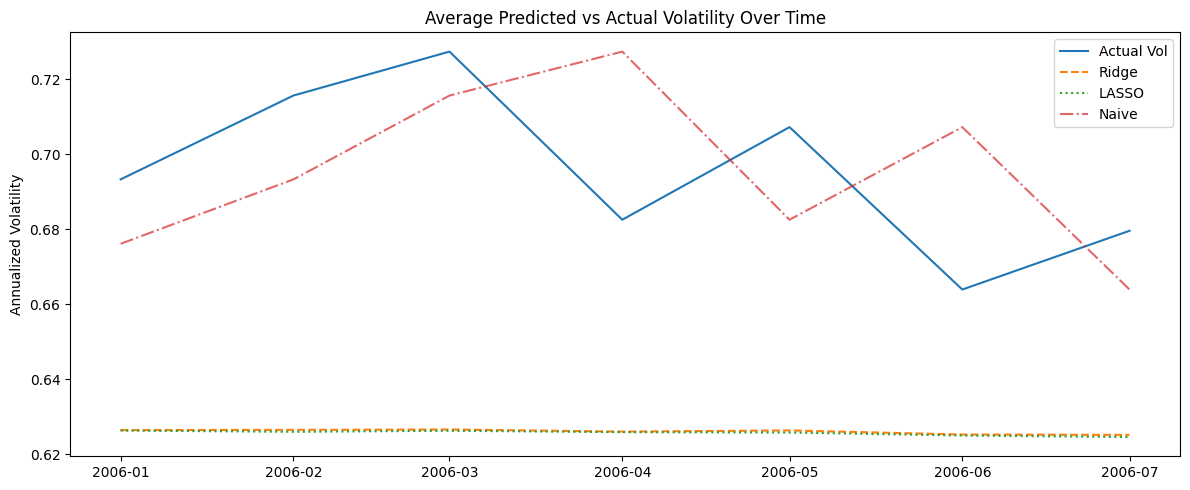

=== CHECK 11: Visual check ===
Predictions should track actual vol with spikes around 2001, 2008, 2020.
If predictions are flat or wildly off, review feature construction.


In [27]:
# ============================================================
# VISUAL CHECK: Predicted vs Actual vol over time
# Averaged across all stocks per month
# ============================================================

monthly_avg = df_results.groupby("date").agg(
    actual_vol     = ("actual_vol",     "mean"),
    pred_vol_ridge = ("pred_vol_ridge", "mean"),
    pred_vol_lasso = ("pred_vol_lasso", "mean"),
    pred_vol_naive = ("pred_vol_naive", "mean"),
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg["date"], monthly_avg["actual_vol"],
         label="Actual Vol", linewidth=1.5)
plt.plot(monthly_avg["date"], monthly_avg["pred_vol_ridge"],
         label="Ridge", linestyle="--")
plt.plot(monthly_avg["date"], monthly_avg["pred_vol_lasso"],
         label="LASSO", linestyle=":")
plt.plot(monthly_avg["date"], monthly_avg["pred_vol_naive"],
         label="Naive", linestyle="-.", alpha=0.7)
plt.title("Average Predicted vs Actual Volatility Over Time")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.tight_layout()
plt.show()

# ---- CHECK 11: Predictions track actual vol visually ----
print("=== CHECK 11: Visual check ===")
print("Predictions should track actual vol with spikes around 2001, 2008, 2020.")
print("If predictions are flat or wildly off, review feature construction.")

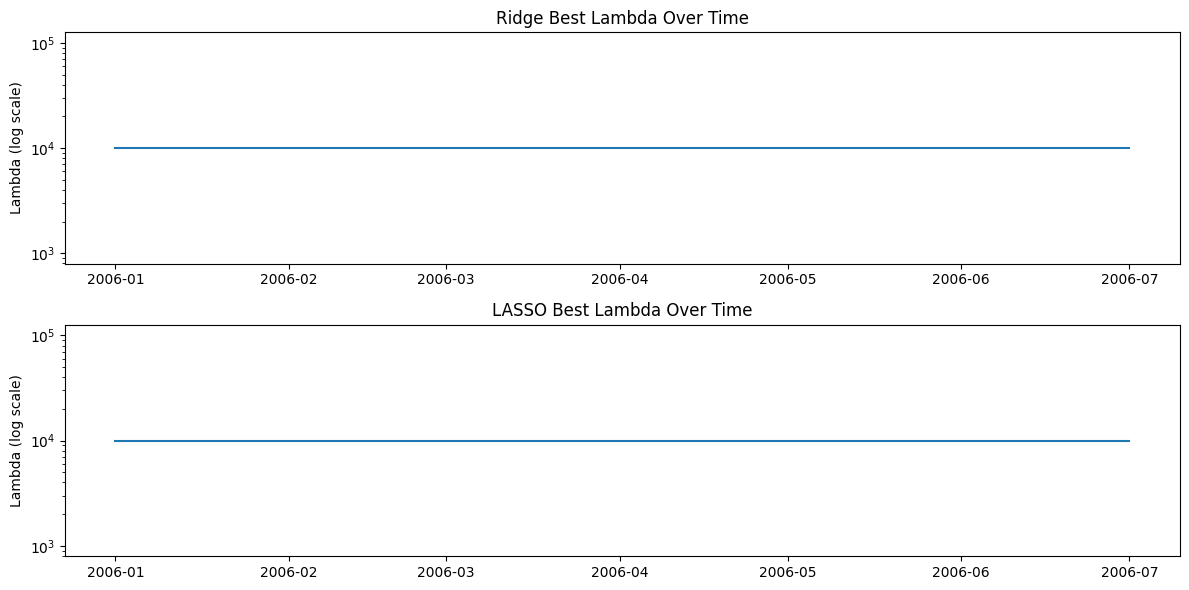

=== CHECK 12: Lambda Stability ===
Ridge lambda range: 10000.0000 to 10000.0000
LASSO lambda range: 10000.0000 to 10000.0000
If best lambda frequently hits grid boundary (1e-4 or 1e4),
widen the grid with np.logspace(-6, 6, 100).


In [28]:
# ============================================================
# CHECK: Are the chosen lambdas stable over time?
# If they jump around a lot it suggests the grid needs widening
# ============================================================

lambda_df = df_results.groupby("date").agg(
    ridge_lambda = ("ridge_best_lambda", "first"),
    lasso_lambda = ("lasso_best_lambda", "first"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(lambda_df["date"], lambda_df["ridge_lambda"])
axes[0].set_yscale("log")
axes[0].set_title("Ridge Best Lambda Over Time")
axes[0].set_ylabel("Lambda (log scale)")

axes[1].plot(lambda_df["date"], lambda_df["lasso_lambda"])
axes[1].set_yscale("log")
axes[1].set_title("LASSO Best Lambda Over Time")
axes[1].set_ylabel("Lambda (log scale)")

plt.tight_layout()
plt.show()

print("=== CHECK 12: Lambda Stability ===")
print(f"Ridge lambda range: {lambda_df['ridge_lambda'].min():.4f} "
      f"to {lambda_df['ridge_lambda'].max():.4f}")
print(f"LASSO lambda range: {lambda_df['lasso_lambda'].min():.4f} "
      f"to {lambda_df['lasso_lambda'].max():.4f}")
print("If best lambda frequently hits grid boundary (1e-4 or 1e4),")
print("widen the grid with np.logspace(-6, 6, 100).")

In [29]:
# Save for use in backtesting (Phase 4)
df_results.to_parquet("model_a_predictions.parquet", index=False)

print("=== DONE ===")
print("Results saved to model_a_predictions.parquet")
print()
print("Columns available for backtesting:")
print(df_results.columns.tolist())

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.